# Useful Notebook: Re-Evaluate Models Testing Data Performance Using an Alternative Decision Threshold
**This notebook will allow users to (1) re-evaluate all trained models on the respective testing datasets using a decision threshold other than the default 0.5, (2) re-generate metric evaluation boxplots comparing algorithm performance using this new decision threshold, and (3) re-run statistical significance analyses comparing algorithm performance using this new decision threshold.**

*This notebook is designed to run after having run STREAMLINE (at least phases 1-6) and will use the files from a specific STREAMLINE experiment folder, as well as save new output files to that same folder.*

***
## Notebook Details
Allows users to specify alternative decision thresholds (rather than the standard 0.5 probability) and re-evaluate algorithm performane metrics. All results are saved in the same locations in the experiment folder as their original counterparts (with a modified name). 

Warning: Since this is run on testing data, this should not be used to pick a new decision threshold (otherwise the resulting model+threshold may be overfit). 
 

***
## Notebook Run Parameters
* This notbook has been set up to run 'as-is' on the experiment folder generated when running the demo of STREAMLINE in any mode (if no run parameters were changed). 
* If you have run STREAMLINE on different target data or saved the experiment to some other folder outside of STREAMLINE, you need to edit `experiment_path` below to point to the respective experiment folder.

In [1]:
experiment_path = "/Users/harshbandhey/Local/Cedars/Urbslab/STREAMLINEv3New/test/out_full_pipeline/DemoExp" # path the target experiment folder 
targetDataName = None # 'None' if user wants to generate visualizations for all analyzed datasets
algorithms = [] # use empty list if user wishes re-evaluate all modeling algorithms that were run in pipeline.
threshold = 0.2 # Threshold of case probability used to predict case (typically 0.5 by default in modeling)
plot_metric_boxplots = True # Plot new boxplots for each metric using new threshold.
run_sig_test = True # Rerun non-parametric significance testing between all algorithms for each metric.
name_modifier = '_T_'+str(threshold) # Modifies names of stats files to avoid overwriting originals (This can be left as is or altered)

***
## Housekeeping
### Import Packages

In [2]:
import os
import pandas as pd
import pickle
from statistics import mean,stdev
import numpy as np
from scipy import stats
interp = np.interp
# Evalutation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn import metrics
import csv
import matplotlib.pyplot as plt
import copy

import warnings
warnings.filterwarnings('ignore')

# Jupyter Notebook Hack: This code ensures that the results of multiple commands within a given cell are all displayed, rather than just the last. 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

### Automatically detect data folder names

In [3]:
# Get dataset paths for all completed dataset analyses in experiment folder
experiment_name = experiment_path.split('/')[-1]
remove_list = {
    '.DS_Store', 'metadata.pickle', 'metadata.csv', 'algInfo.pickle',
    'DatasetComparisons', 'jobs', 'jobsCompleted', 'logs', 'KeyFileCopy', 'dask_logs',
    'reporting', 'reporting_replication', 'run_params.pickle', 'runtime',
    experiment_name + '_STREAMLINE_Report.pdf'
}

datasets = []
for d in sorted(os.listdir(experiment_path)):
    dpath = os.path.join(experiment_path, d)
    if d in remove_list or not os.path.isdir(dpath):
        continue
    has_exploratory = os.path.isdir(os.path.join(dpath, 'exploratory'))
    has_model_data = os.path.isdir(os.path.join(dpath, 'model_evaluation')) or os.path.isdir(os.path.join(dpath, 'models'))
    if has_exploratory and has_model_data:
        datasets.append(d)

print("Analyzed Datasets: " + str(datasets))

Analyzed Datasets: ['hcc_data', 'hcc_data_custom']


### Load other necessary parameters

In [4]:
# Unpickle metadata from previous phase
file = open(experiment_path+'/'+"metadata.pickle", 'rb')
metadata = pickle.load(file)
file.close()
# Load variables specified earlier in the pipeline from metadata
outcome_label = metadata.get('Outcome Label', metadata.get('Class Label', 'Class'))
instance_label = metadata['Instance Label']
cv_partitions = int(metadata['CV Partitions'])
sig_cutoff =float(metadata['Statistical Significance Cutoff'])
primary_metirc = metadata.get('Primary Metric', metadata.get('P6 Scoring Metric', metadata.get('P8 Scoring Metric', 'balanced_accuracy')))

requested_algorithms = list(algorithms) if isinstance(algorithms, list) else []

# Unpickle algorithm information from previous phase
alg_info_path = os.path.join(experiment_path, "algInfo.pickle")
if os.path.exists(alg_info_path):
    with open(alg_info_path, "rb") as file:
        algInfo = pickle.load(file)
else:
    algInfo = {}

algorithms = []
abbrev = {}
colors = {}
for key, value in algInfo.items():
    if isinstance(value, (list, tuple)) and len(value) > 0 and bool(value[0]):
        algorithms.append(key)
        abbrev[key] = value[1] if len(value) > 1 else key
        colors[key] = value[2] if len(value) > 2 else None

# Fallback: infer algorithms from current output layout
if not algorithms:
    inferred = set()
    scan_datasets = [d for d in datasets if os.path.isdir(os.path.join(experiment_path, d))]
    for ds_name in scan_datasets:
        model_dir = os.path.join(experiment_path, ds_name, "models", "pickledModels")
        if os.path.isdir(model_dir):
            for fname in os.listdir(model_dir):
                if fname.endswith('.pickle') and '_' in fname:
                    inferred.add(fname.rsplit('_', 1)[0])
        metric_dir = os.path.join(experiment_path, ds_name, "model_evaluation", "metrics_by_cv")
        if os.path.isdir(metric_dir):
            for fname in os.listdir(metric_dir):
                if fname.endswith('.json') and '_CV_' in fname:
                    inferred.add(fname.split('_CV_')[0])
    for abr in sorted(inferred):
        algorithms.append(abr)
        abbrev[abr] = abr
        colors[abr] = None

if requested_algorithms:
    req = set(requested_algorithms)
    filtered = [a for a in algorithms if a in req or abbrev.get(a) in req]
    if filtered:
        algorithms = filtered

palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]
for idx, key in enumerate(algorithms):
    if colors.get(key) is None:
        colors[key] = palette[idx % len(palette)]

print("Algorithms Ran: " + str(algorithms))

Algorithms Ran: ['LR', 'NB', 'SVM']


## Define Necessary Methods

In [5]:
def classEval(y_true, y_pred):
    """ Calculates standard classification metrics including:
    True positives, false positives, true negative, false negatives, standard accuracy, balanced accuracy
    recall, precision, f1 score, negative predictive value, likelihood ratio positive, and likelihood ratio negative"""
    #Calculate true positive, true negative, false positive, and false negative.
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    #Calculate Accuracy metrics
    ac = accuracy_score(y_true, y_pred)
    bac = balanced_accuracy_score(y_true, y_pred)
    #Calculate Precision and Recall
    re = recall_score(y_true, y_pred)
    pr = precision_score(y_true, y_pred)
    #Calculate F1 score
    f1 = f1_score(y_true, y_pred)
    # Calculate specificity
    if tn == 0 and fp == 0:
        sp = 0
    else:
        sp = tn / float(tn + fp)
    # Calculate Negative predictive value
    if tn == 0 and fn == 0:
        npv = 0
    else:
        npv = tn/float(tn+fn)
    # Calculate likelihood ratio postive
    if sp == 1:
        lrp = 0
    else:
        lrp = re/float(1-sp)
    # Calculate likeliehood ratio negative
    if sp == 0:
        lrm = 0
    else:
        lrm = (1-re)/float(sp)
    return [bac, ac, f1, re, sp, pr, tp, tn, fp, fn, npv, lrp, lrm]

In [6]:
def saveMetricMeans(full_path,metrics,metric_dict,name_modifier):
    """ Exports csv file with average metric values (over all CVs) for each ML modeling algorithm"""
    with open(full_path+'/model_evaluation/Summary_performance_mean'+name_modifier+'.csv',mode='w', newline="") as file:
        writer = csv.writer(file, delimiter=',', quotechar='"', quoting=csv.QUOTE_MINIMAL)
        e = ['']
        e.extend(metrics)
        writer.writerow(e) #Write headers (balanced accuracy, etc.)
        for algorithm in metric_dict:
            astats = []
            for l in list(metric_dict[algorithm].values()):
                l = [float(i) for i in l]
                meani = mean(l)
                std = stdev(l)
                astats.append(str(meani))
            toAdd = [algorithm]
            toAdd.extend(astats)
            writer.writerow(toAdd)
    file.close()

In [7]:
def saveMetricStd(full_path,metrics,metric_dict,name_modifier):
    """ Exports csv file with metric value standard deviations (over all CVs) for each ML modeling algorithm"""
    with open(full_path + '/model_evaluation/Summary_performance_std'+name_modifier+'.csv', mode='w', newline="") as file:
        writer = csv.writer(file, delimiter=',', quotechar='"', quoting=csv.QUOTE_MINIMAL)
        e = ['']
        e.extend(metrics)
        writer.writerow(e)  # Write headers (balanced accuracy, etc.)
        for algorithm in metric_dict:
            astats = []
            for l in list(metric_dict[algorithm].values()):
                l = [float(i) for i in l]
                std = stdev(l)
                astats.append(str(std))
            toAdd = [algorithm]
            toAdd.extend(astats)
            writer.writerow(toAdd)
    file.close()

In [8]:
def metricBoxplots(full_path,metrics,algorithms,metric_dict,name_modifier):
    """ Export boxplots comparing algorithm performance for each standard metric"""
    if not os.path.exists(full_path + '/model_evaluation/metricBoxplots'):
        os.mkdir(full_path + '/model_evaluation/metricBoxplots')
    for metric in metrics:
        tempList = []
        for algorithm in algorithms:
            tempList.append(metric_dict[algorithm][metric])
        td = pd.DataFrame(tempList)
        td = td.transpose()
        td.columns = algorithms
        #Generate boxplot
        boxplot = td.boxplot(column=algorithms,rot=90)
        #Specify plot labels
        plt.ylabel(str(metric))
        plt.xlabel('ML Algorithm')
        #Export and/or show plot
        plt.savefig(full_path + '/model_evaluation/metricBoxplots/Compare_'+metric+name_modifier+'.png', bbox_inches="tight")
        plt.show()

In [9]:
def kruskalWallis(full_path,metrics,algorithms,metric_dict,sig_cutoff,name_modifier):
    """ Apply non-parametric Kruskal Wallis one-way ANOVA on ranks. Determines if there is a statistically significant difference in algorithm performance across CV runs.
    Completed for each standard metric separately."""
    # Create directory to store significance testing results (used for both Kruskal Wallis and MannWhitney U-test)
    if not os.path.exists(full_path + '/model_evaluation/statistical_comparisons'):
        os.mkdir(full_path + '/model_evaluation/statistical_comparisons')
    #Create dataframe to store analysis results for each metric
    label = ['Statistic', 'P-Value', 'Sig(*)']
    kruskal_summary = pd.DataFrame(index=metrics, columns=label)
    #Apply Kruskal Wallis test for each metric
    for metric in metrics:
        tempArray = []
        for algorithm in algorithms:
            tempArray.append(metric_dict[algorithm][metric])
        try:
            result = stats.kruskal(*tempArray)
        except:
            result = [tempArray[0],1]
        kruskal_summary.at[metric, 'Statistic'] = str(round(result[0], 6))
        kruskal_summary.at[metric, 'P-Value'] = str(round(result[1], 6))
        if result[1] < sig_cutoff:
            kruskal_summary.at[metric, 'Sig(*)'] = str('*')
        else:
            kruskal_summary.at[metric, 'Sig(*)'] = str('')
    #Export analysis summary to .csv file
    kruskal_summary.to_csv(full_path + '/model_evaluation/statistical_comparisons/KruskalWallis'+name_modifier+'.csv')
    return kruskal_summary

In [10]:
def wilcoxonRank(full_path,metrics,algorithms,metric_dict,kruskal_summary,sig_cutoff,name_modifier):
    """ Apply non-parametric Wilcoxon signed-rank test (pairwise comparisons). If a significant Kruskal Wallis algorithm difference was found for a given metric, Wilcoxon tests individual algorithm pairs
    to determine if there is a statistically significant difference in algorithm performance across CV runs. Test statistic will be zero if all scores from one set are
    larger than the other."""
    for metric in metrics:
        if kruskal_summary['Sig(*)'][metric] == '*':
            wilcoxon_stats = []
            done = []
            for algorithm1 in algorithms:
                for algorithm2 in algorithms:
                    if not [algorithm1,algorithm2] in done and not [algorithm2,algorithm1] in done and algorithm1 != algorithm2:
                        set1 = metric_dict[algorithm1][metric]
                        set2 = metric_dict[algorithm2][metric]
                        #handle error when metric values are equal for both algorithms
                        combined = copy.deepcopy(set1)
                        combined.extend(set2)
                        if all(x==combined[0] for x in combined): #Check if all nums are equal in sets
                            report = ['NA',1]
                        else: # Apply Wilcoxon Rank Sum test
                            report = stats.wilcoxon(set1,set2)
                        #Summarize test information in list
                        tempstats = [algorithm1,algorithm2,report[0],report[1],'']
                        if report[1] < sig_cutoff:
                            tempstats[4] = '*'
                        wilcoxon_stats.append(tempstats)
                        done.append([algorithm1,algorithm2])
            #Export test results
            wilcoxon_stats_df = pd.DataFrame(wilcoxon_stats)
            wilcoxon_stats_df.columns = ['Algorithm 1', 'Algorithm 2', 'Statistic', 'P-Value', 'Sig(*)']
            wilcoxon_stats_df.to_csv(full_path + '/model_evaluation/statistical_comparisons/WilcoxonRank_'+metric+name_modifier+'.csv', index=False)

In [11]:
def mannWhitneyU(full_path,metrics,algorithms,metric_dict,kruskal_summary,sig_cutoff,name_modifier):
    """ Apply non-parametric Mann Whitney U-test (pairwise comparisons). If a significant Kruskal Wallis algorithm difference was found for a given metric, Mann Whitney tests individual algorithm pairs
    to determine if there is a statistically significant difference in algorithm performance across CV runs. Test statistic will be zero if all scores from one set are
    larger than the other."""
    for metric in metrics:
        if kruskal_summary['Sig(*)'][metric] == '*':
            mann_stats = []
            done = []
            for algorithm1 in algorithms:
                for algorithm2 in algorithms:
                    if not [algorithm1,algorithm2] in done and not [algorithm2,algorithm1] in done and algorithm1 != algorithm2:
                        set1 = metric_dict[algorithm1][metric]
                        set2 = metric_dict[algorithm2][metric]
                        #handle error when metric values are equal for both algorithms
                        combined = copy.deepcopy(set1)
                        combined.extend(set2)
                        if all(x==combined[0] for x in combined): #Check if all nums are equal in sets
                            report = ['NA',1]
                        else: #Apply Mann Whitney U test
                            report = stats.mannwhitneyu(set1,set2)
                        #Summarize test information in list
                        tempstats = [algorithm1,algorithm2,report[0],report[1],'']
                        if report[1] < sig_cutoff:
                            tempstats[4] = '*'
                        mann_stats.append(tempstats)
                        done.append([algorithm1,algorithm2])
            #Export test results
            mann_stats_df = pd.DataFrame(mann_stats)
            mann_stats_df.columns = ['Algorithm 1', 'Algorithm 2', 'Statistic', 'P-Value', 'Sig(*)']
            mann_stats_df.to_csv(full_path + '/model_evaluation/statistical_comparisons/MannWhitneyU_'+metric+name_modifier+'.csv', index=False)

## Run New Testing Evaluation and Metric Boxplot Generation

Vizualized Datasets: ['hcc_data', 'hcc_data_custom']
---------------------------------------
hcc_data
---------------------------------------


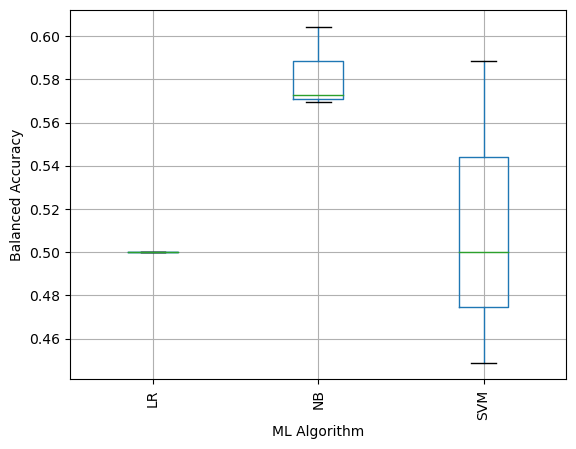

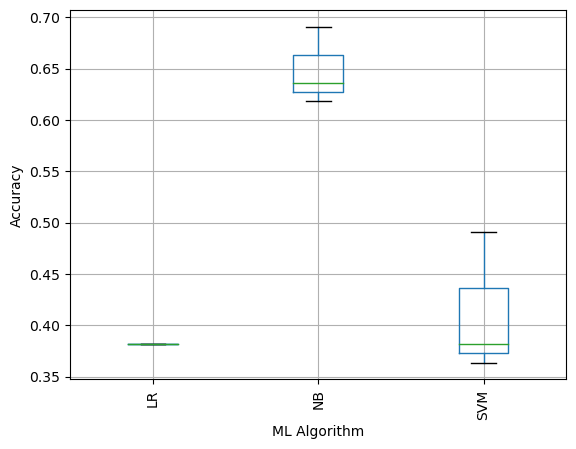

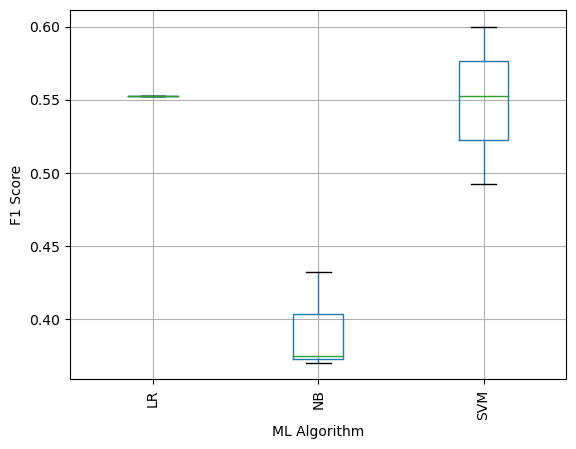

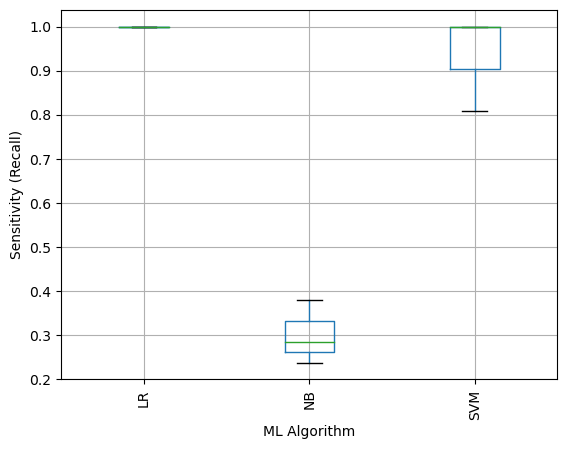

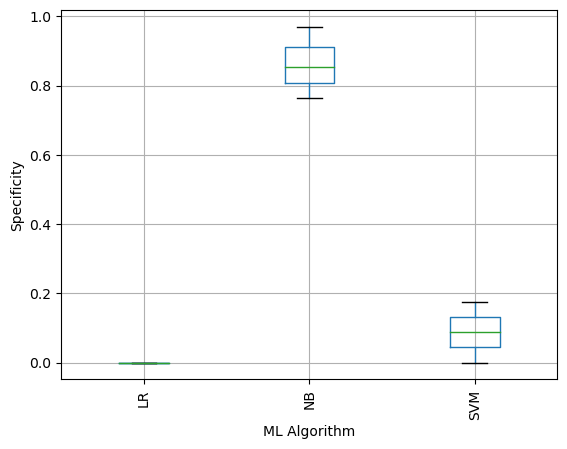

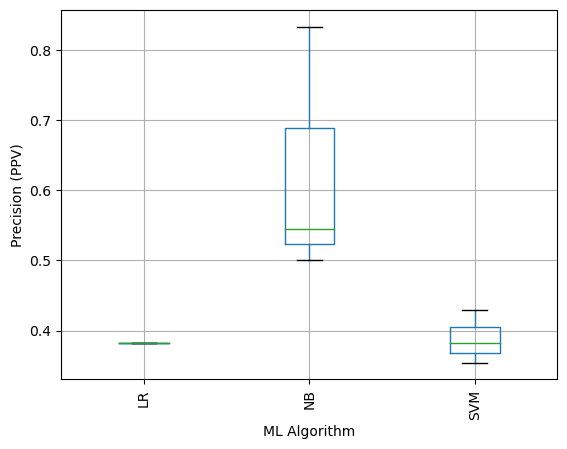

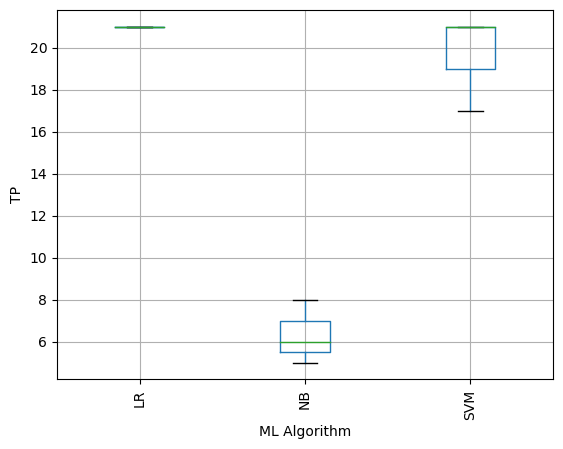

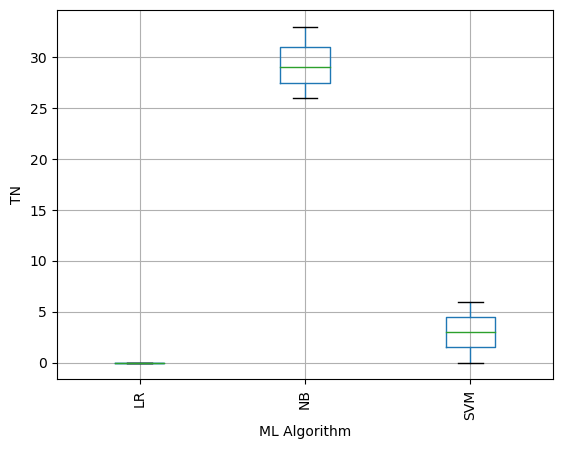

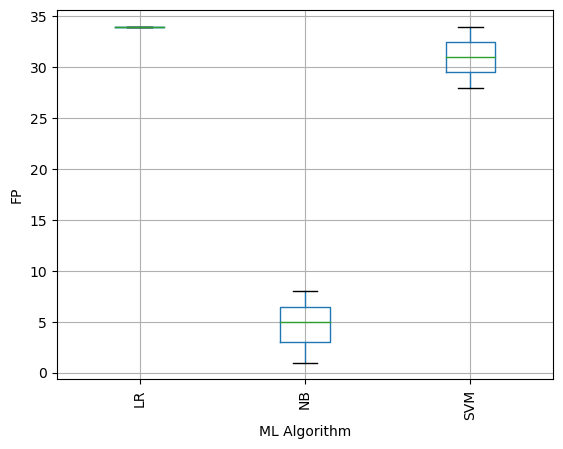

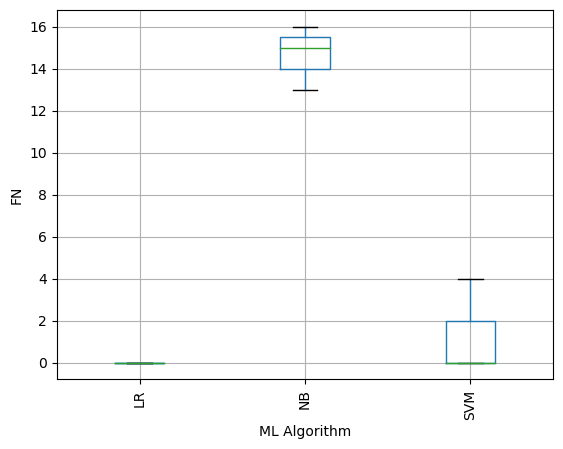

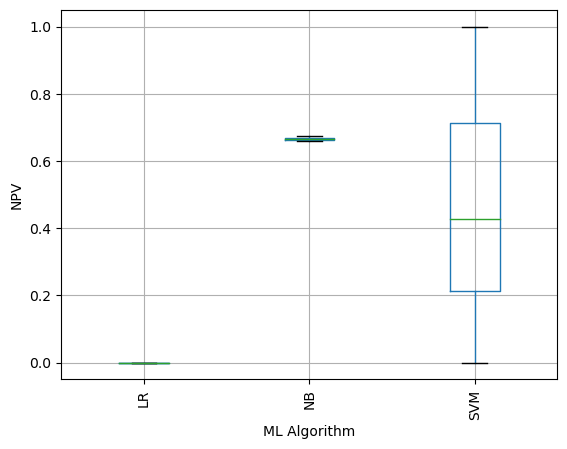

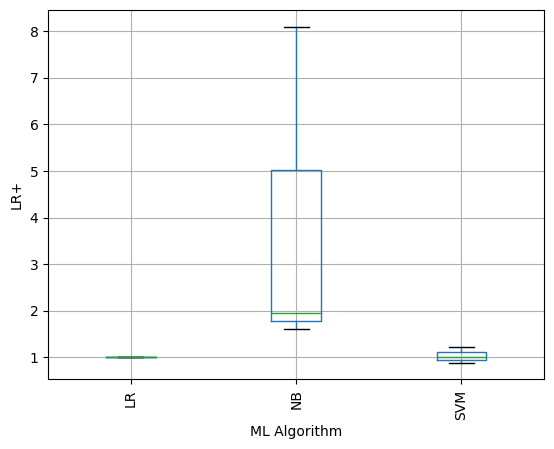

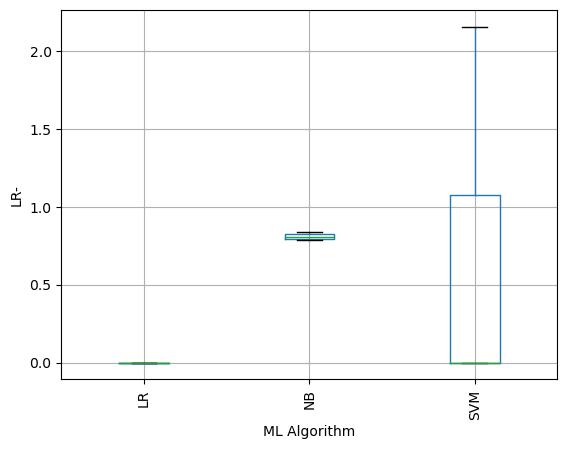

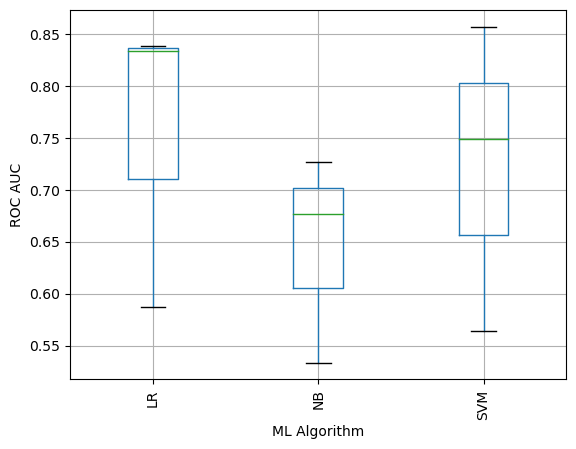

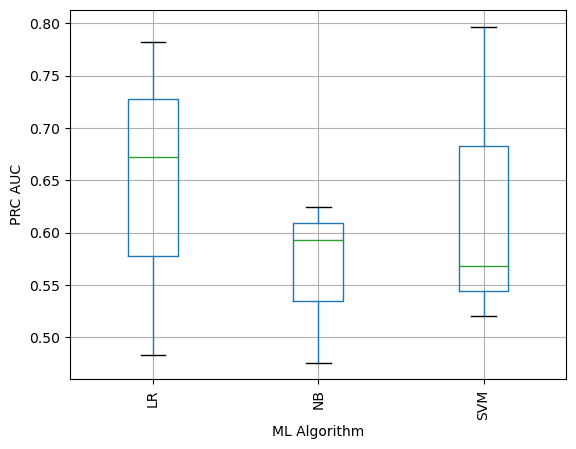

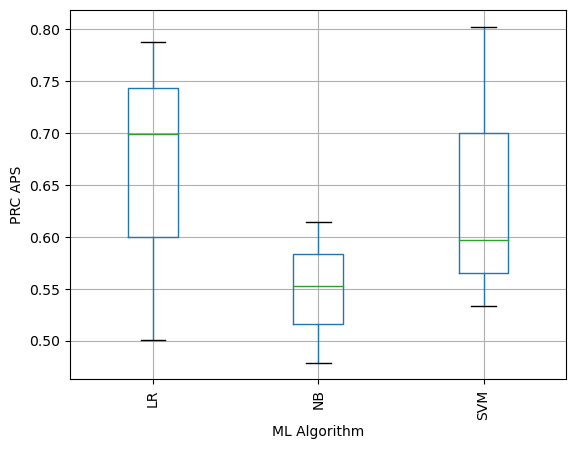

---------------------------------------
hcc_data_custom
---------------------------------------


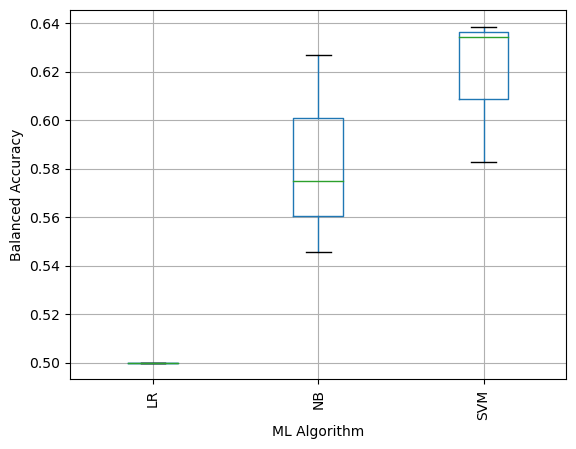

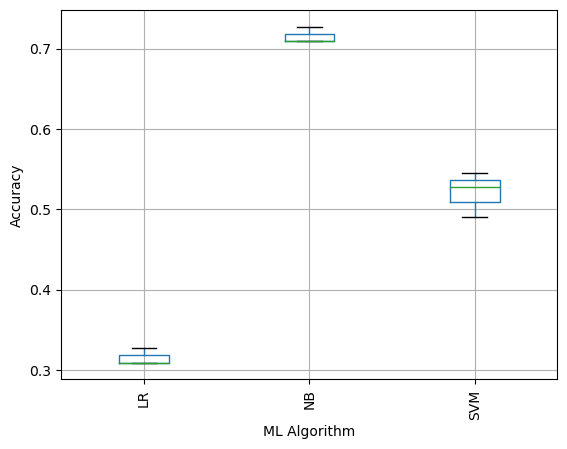

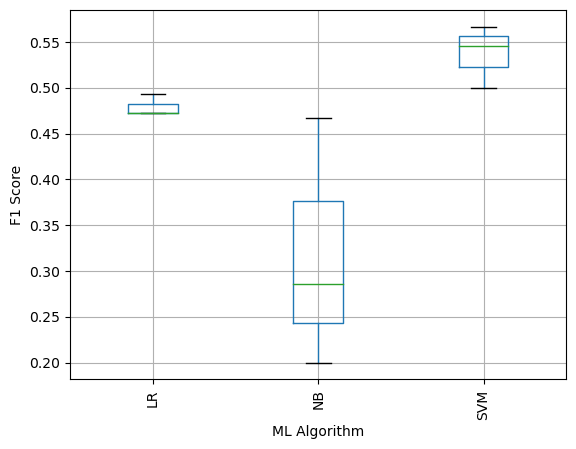

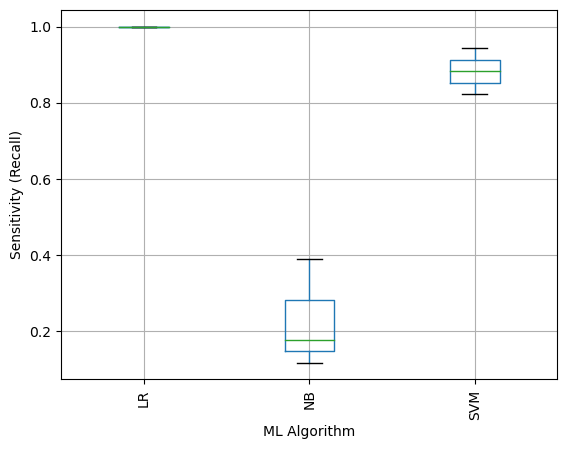

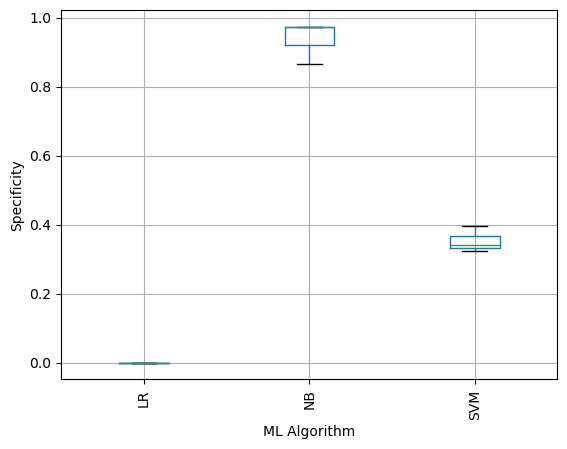

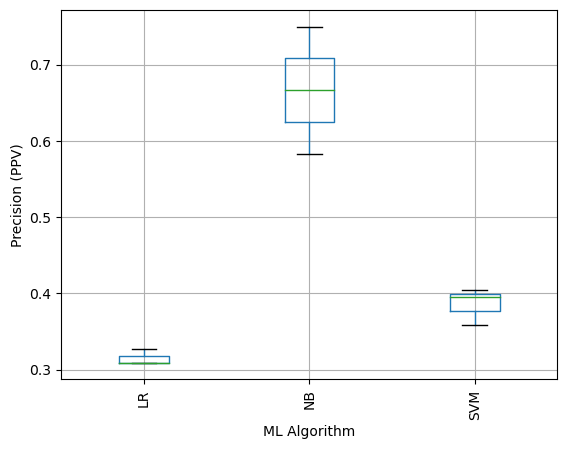

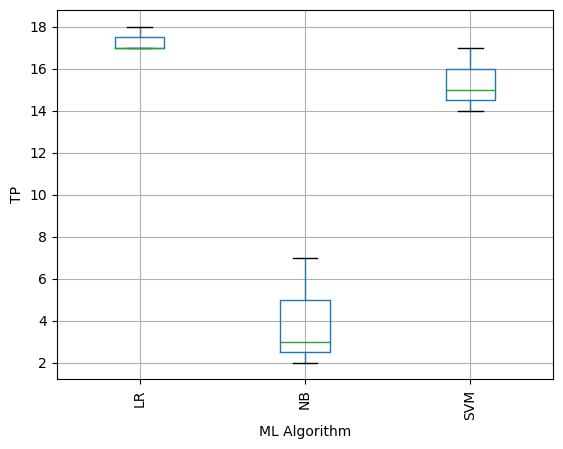

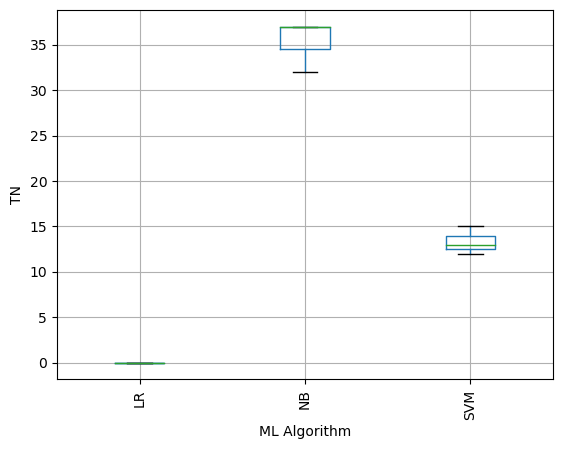

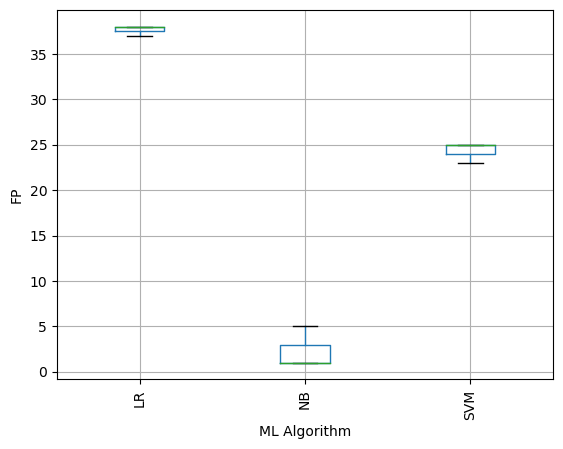

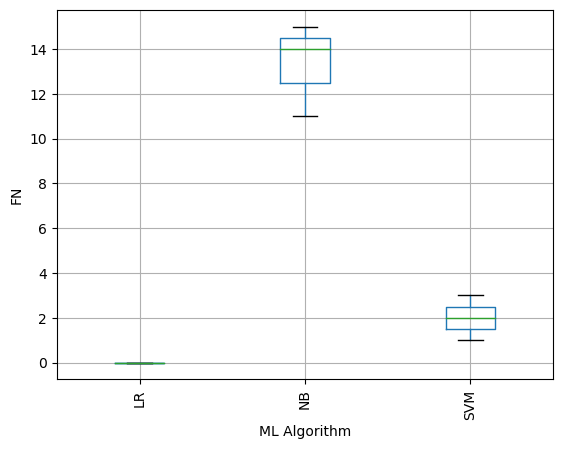

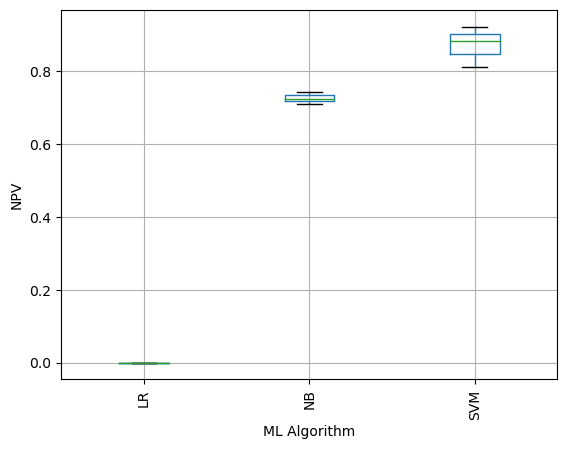

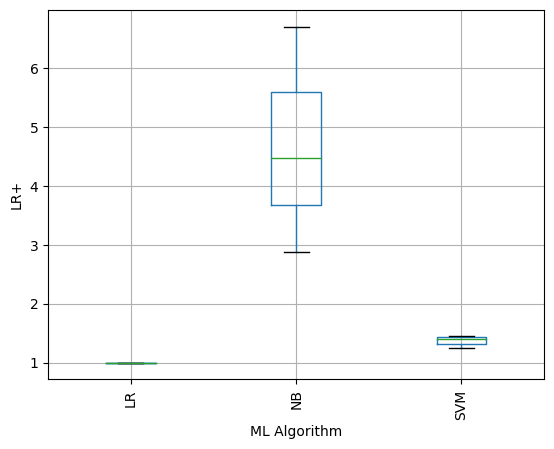

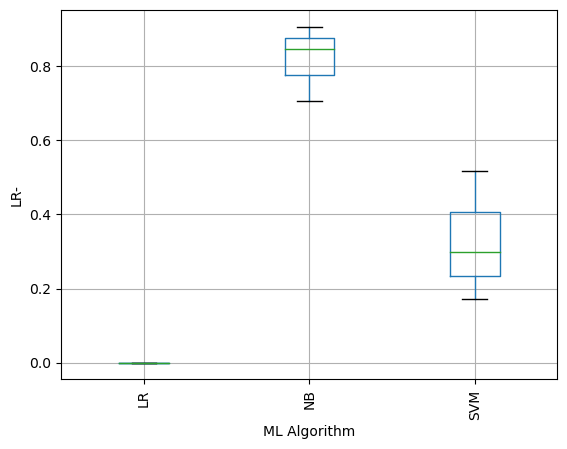

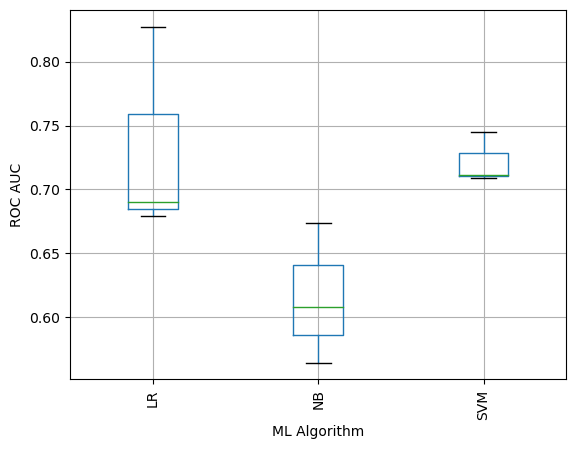

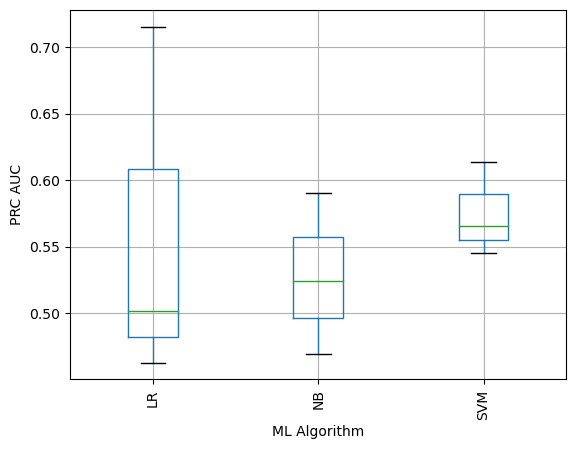

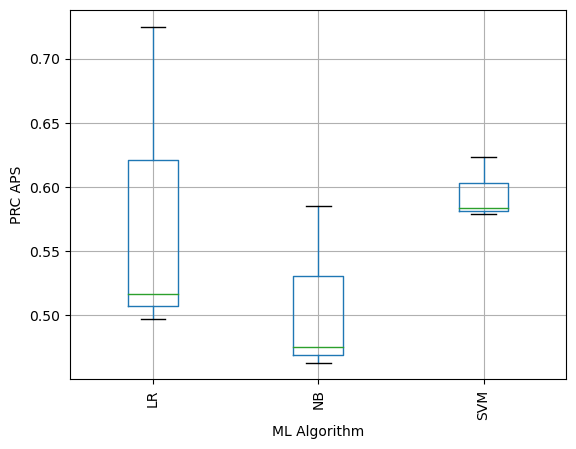

In [12]:
if targetDataName not in (None, 'None'):
    datasets = [d for d in datasets if d == targetDataName]
print("Vizualized Datasets: " + str(datasets))

if not algorithms:
    raise ValueError("No algorithms discovered. Check experiment path and model outputs.")

for each in datasets: #each analyzed dataset to make plots for
    print("---------------------------------------")
    print(each)
    print("---------------------------------------")
    full_path = experiment_path+'/'+each
    metric_dict = {}

    for algorithm in algorithms: #loop through algorithms
        s_bac = []
        s_ac = []
        s_f1 = []
        s_re = []
        s_sp = []
        s_pr = []
        s_tp = []
        s_tn = []
        s_fp = []
        s_fn = []
        s_npv = []
        s_lrp = []
        s_lrm = []
        aucs = []
        praucs = []
        aveprecs = []

        for cvCount in range(0,cv_partitions):
            test_file_path = full_path + '/CVDatasets/' + each + "_CV_" + str(cvCount) + "_Test.csv"
            test = pd.read_csv(test_file_path)
            testY = test[outcome_label].values
            drop_cols = [outcome_label]
            if instance_label != 'None' and instance_label in test.columns:
                drop_cols.append(instance_label)
            testX = test.drop(columns=drop_cols).values
            del test

            model_file = full_path+'/models/pickledModels/'+abbrev[algorithm]+"_"+str(cvCount)+'.pickle'
            if not os.path.exists(model_file):
                print("Missing model file: " + model_file)
                continue
            with open(model_file, 'rb') as file:
                model = pickle.load(file)

            if not hasattr(model, 'predict_proba'):
                print("Skipping {} CV {} (predict_proba unavailable)".format(algorithm, cvCount))
                continue

            probas_all = model.predict_proba(testX)
            if len(probas_all.shape) != 2 or probas_all.shape[1] < 2:
                print("Skipping {} CV {} (requires probability output)".format(algorithm, cvCount))
                continue

            classes = list(getattr(model, 'classes_', range(probas_all.shape[1])))
            if probas_all.shape[1] > 2 or len(np.unique(testY)) > 2:
                positive_class = 1 if 1 in classes else classes[0]
                class_index = classes.index(positive_class)
                evalY = (testY == positive_class).astype(int)
                probas_pos = probas_all[:, class_index]
            else:
                evalY = testY
                probas_pos = probas_all[:,1]

            if len(np.unique(evalY)) < 2:
                print("Skipping {} CV {} (only one class present after conversion)".format(algorithm, cvCount))
                continue

            y_pred = probas_pos > threshold
            metricList = classEval(evalY, y_pred)

            fpr, tpr, _ = metrics.roc_curve(evalY, probas_pos)
            roc_auc = auc(fpr, tpr)

            prec, recall, _ = metrics.precision_recall_curve(evalY, probas_pos)
            prec, recall = prec[::-1], recall[::-1]
            prec_rec_auc = auc(recall, prec)
            ave_prec = metrics.average_precision_score(evalY, probas_pos)

            s_bac.append(metricList[0])
            s_ac.append(metricList[1])
            s_f1.append(metricList[2])
            s_re.append(metricList[3])
            s_sp.append(metricList[4])
            s_pr.append(metricList[5])
            s_tp.append(metricList[6])
            s_tn.append(metricList[7])
            s_fp.append(metricList[8])
            s_fn.append(metricList[9])
            s_npv.append(metricList[10])
            s_lrp.append(metricList[11])
            s_lrm.append(metricList[12])
            aucs.append(roc_auc)
            praucs.append(prec_rec_auc)
            aveprecs.append(ave_prec)

        if not s_bac:
            print("No valid CV predictions for algorithm: " + str(algorithm))
            continue

        results = {
            'Balanced Accuracy': s_bac, 'Accuracy': s_ac, 'F1 Score': s_f1,
            'Sensitivity (Recall)': s_re, 'Specificity': s_sp, 'Precision (PPV)': s_pr,
            'TP': s_tp, 'TN': s_tn, 'FP': s_fp, 'FN': s_fn,
            'NPV': s_npv, 'LR+': s_lrp, 'LR-': s_lrm,
            'ROC AUC': aucs, 'PRC AUC': praucs, 'PRC APS': aveprecs
        }
        dr = pd.DataFrame(results)
        filepath = full_path+'/model_evaluation/'+abbrev[algorithm]+"_performance"+name_modifier+".csv"
        dr.to_csv(filepath, header=True, index=False)
        metric_dict[algorithm] = results

    if not metric_dict:
        print("No algorithm metrics available for dataset: " + each)
        continue

    my_metrics = list(next(iter(metric_dict.values())).keys())

    saveMetricMeans(full_path,my_metrics,metric_dict,name_modifier)
    saveMetricStd(full_path,my_metrics,metric_dict,name_modifier)

    if plot_metric_boxplots:
        metricBoxplots(full_path,my_metrics,list(metric_dict.keys()),metric_dict,name_modifier)

    if run_sig_test and len(metric_dict) > 1:
        compare_algs = list(metric_dict.keys())
        kruskal_summary = kruskalWallis(full_path,my_metrics,compare_algs,metric_dict,sig_cutoff,name_modifier)
        wilcoxonRank(full_path,my_metrics,compare_algs,metric_dict,kruskal_summary,sig_cutoff,name_modifier)
        mannWhitneyU(full_path,my_metrics,compare_algs,metric_dict,kruskal_summary,sig_cutoff,name_modifier)